# Image Classification with Pre-trained Model
We want to classify the images from the the *bean leaf lesions classification* dataset using a pre-trained model, that is a model that has already been trained on a large dataset, and is able to perform a wide variety of tasks. 

We take this model and fine-tune it to our specific task, meaning that we start from the final weights of the model, and train it for a few more epochs using our train dataset, This operation is called **transfer learning**.

The advantage of this method is that we can obtain a suitable model even with a smaller dataset.

## Dataset and Imports

In [ ]:
import opendatasets as ods
#ods.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:14<00:00, 11.5MB/s] 


In [33]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from torchvision import models # PyTorch pretrained models module
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


## Preprocessing Dataset

In [45]:
train_df = pd.read_csv('bean-leaf-lesions-classification/train.csv')
val_df = pd.read_csv('bean-leaf-lesions-classification/val.csv')

train_df['image:FILE'] = 'bean-leaf-lesions-classification/' + train_df['image:FILE'] 
val_df['image:FILE'] = 'bean-leaf-lesions-classification/' + val_df['image:FILE'] 

print(f"Train: {train_df.shape} | Val: {val_df.shape}")
train_df.head(5)

Train: (1034, 2) | Val: (133, 2)


,image:FILE,category
0,bean-leaf-lesions-classification/train/healthy...,0
1,bean-leaf-lesions-classification/train/healthy...,0
2,bean-leaf-lesions-classification/train/healthy...,0
3,bean-leaf-lesions-classification/train/healthy...,0
4,bean-leaf-lesions-classification/train/healthy...,0


In [23]:
train_df['category'].unique()

array([0, 1, 2])

In [24]:
print(train_df['category'].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


### Transform
We create a transform to preprocess the images and make it so they all have the same size and format.

It is possible to let the images have a bigger size, but more pixels mean more features, so the training becomes slower.

In [25]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

### Create Custom Dataset

In [26]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(dataframe['category']).to(device)

    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        image = image.to(device)

        return image, label

In [46]:
train_ds = CustomImageDataset(dataframe=train_df, transform=transform)
val_ds = CustomImageDataset(dataframe=val_df, transform=transform)

### Visualize Dataset

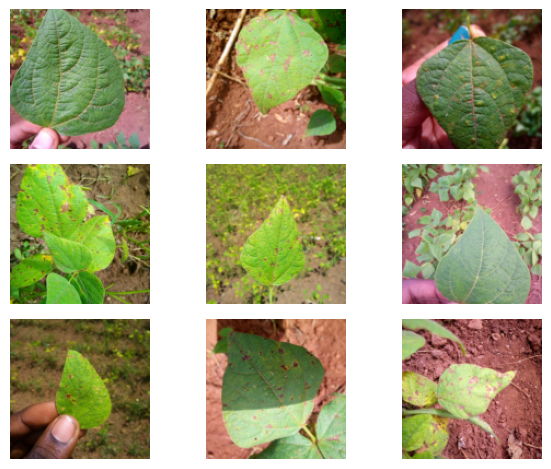

In [28]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = train_ds[np.random.randint(0, train_ds.__len__())][0].cpu()
        axarr[row, col].imshow(image.squeeze().permute(1,2,0))
        axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

## Building the Model

### Hyperparameters

In [29]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

### DataLoader

In [47]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)

### Pre-trained Model

In [ ]:
googlenet_model = models.googlenet(weights = 'DEFAULT')

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001,

We start training the model from the learned weights, so we need to tell the model that its parameters can vary by setting `requires_grad = True`. 

Another option is to leave `requires_grad = False`, so the original weights of the model will not be changed, but add more layers to the model with trainable weights. 

In [36]:
for param in googlenet_model.parameters():
    param.requires_grad = True

In [37]:
# Check last layer
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

Checking the last layer, we see that the model is set to predict 1000 classes, while we need only 3, so we need to change that

In [39]:
# Get the total number of classes
num_classes = len(train_df['category'].unique())
# Change the last linear layer to have 3 output features only
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
# Inspect the new last layer
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [ ]:
# Send model to device
googlenet_model.to(device)

### Loss and Optimizer

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

## Training the Model
Since we are starting from an already built model class, we do not have to define our own model class.

Also we will not carry out inference on the validation dataset during training, but rather use validation data as test data.

In [43]:
total_loss_train_list = []
total_acc_train_list = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        prediction = googlenet_model(inputs).squeeze(1)
        
        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_train += batch_acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    total_loss_train_list.append(round(total_loss_train/1000, 4))
    total_acc_train_list.append(round(total_acc_train/train_ds.__len__() * 100, 4))

    print(f'''Epoch: {epoch+1} | Train Loss: {round(total_loss_train/1000, 4)} | Train Acc: {round(total_acc_train/train_ds.__len__() * 100, 4)}''')



Epoch: 1 | Train Loss: 0.2208 | Train Acc: 61.6054
Epoch: 2 | Train Loss: 0.1593 | Train Acc: 76.1122
Epoch: 3 | Train Loss: 0.1605 | Train Acc: 77.3694
Epoch: 4 | Train Loss: 0.1058 | Train Acc: 84.6228
Epoch: 5 | Train Loss: 0.1109 | Train Acc: 83.7524
Epoch: 6 | Train Loss: 0.0832 | Train Acc: 89.0716
Epoch: 7 | Train Loss: 0.0752 | Train Acc: 90.3288
Epoch: 8 | Train Loss: 0.0741 | Train Acc: 90.4255
Epoch: 9 | Train Loss: 0.0642 | Train Acc: 92.0696
Epoch: 10 | Train Loss: 0.0624 | Train Acc: 92.3598
Epoch: 11 | Train Loss: 0.0511 | Train Acc: 93.4236
Epoch: 12 | Train Loss: 0.0348 | Train Acc: 95.5513
Epoch: 13 | Train Loss: 0.0532 | Train Acc: 93.0368
Epoch: 14 | Train Loss: 0.0365 | Train Acc: 95.8414
Epoch: 15 | Train Loss: 0.0498 | Train Acc: 93.617


## Testing the model

In [48]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in val_loader:
        inputs, labels = data

        prediction = googlenet_model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_test += batch_loss.item()

        batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_test += batch_acc

print(f"Test Acc: {round(total_acc_test/val_ds.__len__() * 100, 4)}")
        

Test Acc: 93.985


## Pure Transfer Learning
In pure transfer learning, we only allow the final layer of the model to change its weights, and leave untouched the weights of all the other layers.

As we can see, the accuracy is much lower, because the model was not able to adapt as well, since it could not modify all its weights. This is a good technique when we add extra layers, because it allows the model to preserve its full knowledge, which is partly lost if we allow all the weights to vary, while still introducing new parameters (weights) that can adapt to the new data we introduce.

In [49]:
googlenet_model_2 = models.googlenet(weights = 'DEFAULT')

for param in googlenet_model_2.parameters():
    param.requires_grad = False

googlenet_model_2.fc = torch.nn.Linear(googlenet_model_2.fc.in_features, num_classes)
googlenet_model_2.fc.requires_grad = True
googlenet_model_2.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001,

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model_2.parameters(), lr=LR)

In [51]:
total_loss_train_list = []
total_acc_train_list = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        prediction = googlenet_model_2(inputs).squeeze(1)
        
        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_train += batch_acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    total_loss_train_list.append(round(total_loss_train/1000, 4))
    total_acc_train_list.append(round(total_acc_train/train_ds.__len__() * 100, 4))

    print(f'''Epoch: {epoch+1} | Train Loss: {round(total_loss_train/1000, 4)} | Train Acc: {round(total_acc_train/train_ds.__len__() * 100, 4)}''')



Epoch: 1 | Train Loss: 0.2399 | Train Acc: 52.5145
Epoch: 2 | Train Loss: 0.1886 | Train Acc: 68.0851
Epoch: 3 | Train Loss: 0.1762 | Train Acc: 71.7602
Epoch: 4 | Train Loss: 0.1833 | Train Acc: 69.5358
Epoch: 5 | Train Loss: 0.185 | Train Acc: 70.4062
Epoch: 6 | Train Loss: 0.1818 | Train Acc: 68.7621
Epoch: 7 | Train Loss: 0.1682 | Train Acc: 73.9845
Epoch: 8 | Train Loss: 0.1713 | Train Acc: 71.7602
Epoch: 9 | Train Loss: 0.1723 | Train Acc: 71.0832
Epoch: 10 | Train Loss: 0.1697 | Train Acc: 72.4371
Epoch: 11 | Train Loss: 0.1636 | Train Acc: 73.7911
Epoch: 12 | Train Loss: 0.1717 | Train Acc: 72.3404
Epoch: 13 | Train Loss: 0.1776 | Train Acc: 71.5667
Epoch: 14 | Train Loss: 0.1719 | Train Acc: 70.8897
Epoch: 15 | Train Loss: 0.1721 | Train Acc: 71.6634


In [52]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in val_loader:
        inputs, labels = data

        prediction = googlenet_model_2(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_test += batch_loss.item()

        batch_acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_test += batch_acc

print(f"Test Acc: {round(total_acc_test/val_ds.__len__() * 100, 4)}")
        

Test Acc: 68.4211
